In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
train_df = pd.read_csv("Datast/train.csv")
test_df = pd.read_csv("Datast/test.csv")
building_df = pd.read_csv("Datast/building_metadata.csv")
weather_train_df = pd.read_csv("Datast/weather_train.csv")
weather_test_df = pd.read_csv("Datast/weather_test.csv")

In [3]:
print("train_df_shape ",train_df.shape)
print("building_df_shape",building_df.shape)
print("weather_train_df_shape",weather_train_df.shape)

train_df_shape  (20216100, 4)
building_df_shape (1449, 6)
weather_train_df_shape (139773, 9)


In [4]:
train_merged = train_df.merge(building_df, on="building_id", how="inner")
main_merged = train_merged.merge(weather_train_df, on=["site_id", "timestamp"], how="inner")
main_merged.columns

Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'primary_use', 'square_feet', 'year_built', 'floor_count',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed'],
      dtype='object')

In [71]:
cp_main=main_merged.copy()

In [72]:
cp_main["meter_reading"] = np.log1p(cp_main["meter_reading"])

In [73]:
cp_main.drop(columns=['building_id','meter','timestamp','site_id','primary_use'],inplace=True)

In [74]:
cp_main.columns

Index(['meter_reading', 'square_feet', 'year_built', 'floor_count',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed'],
      dtype='object')

In [75]:
drop_0readings= list(cp_main[cp_main['meter_reading']==0.0].index)
cp_main.drop(drop_0readings, axis=0, inplace=True)

In [68]:
drop_0readings= list(cp_main[cp_main['precip_depth_1_hr']==0.0].index)
cp_main.drop(drop_0readings, axis=0, inplace=True)

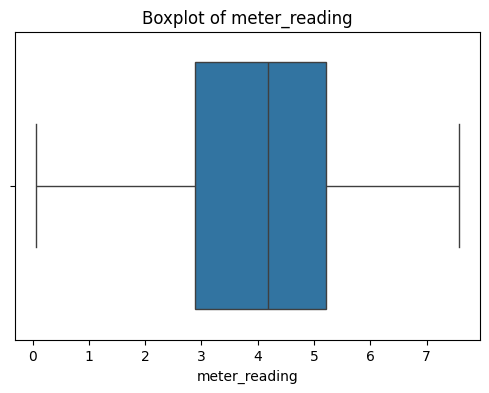

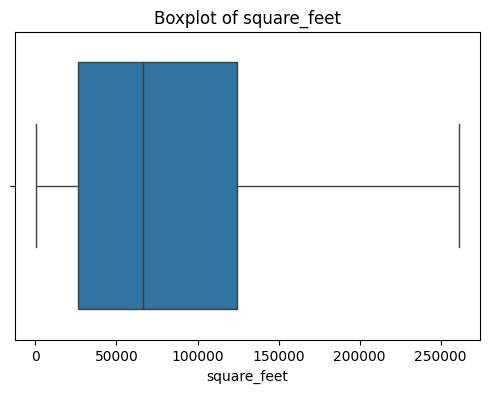

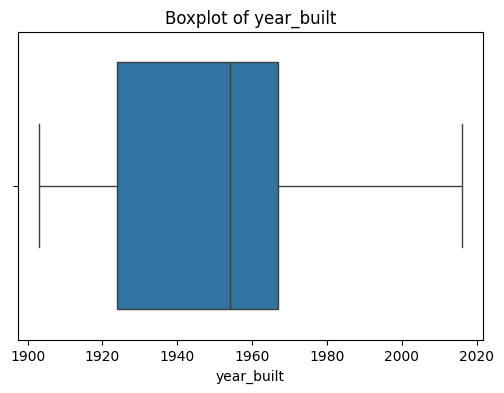

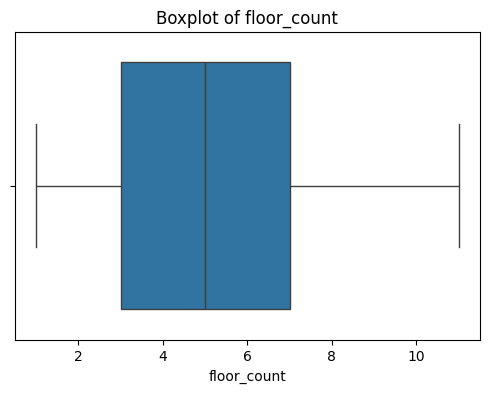

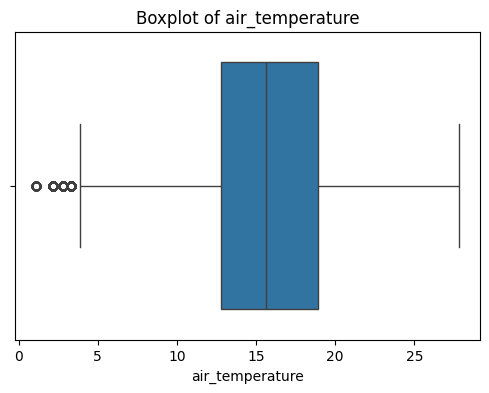

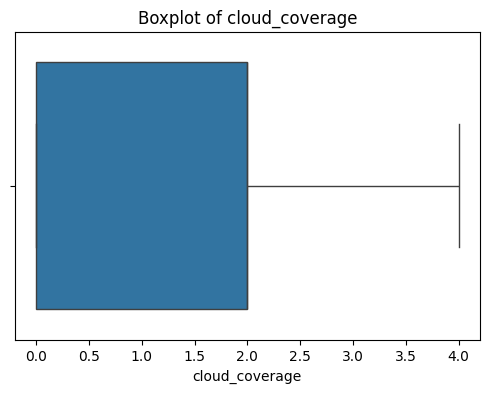

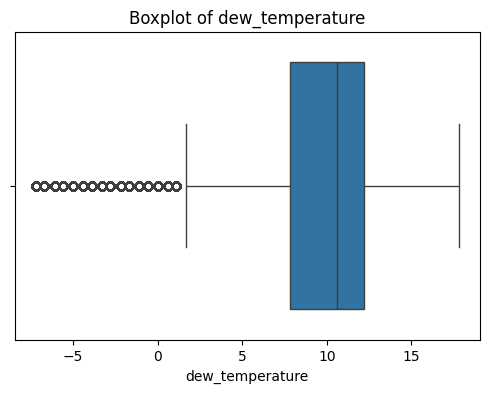

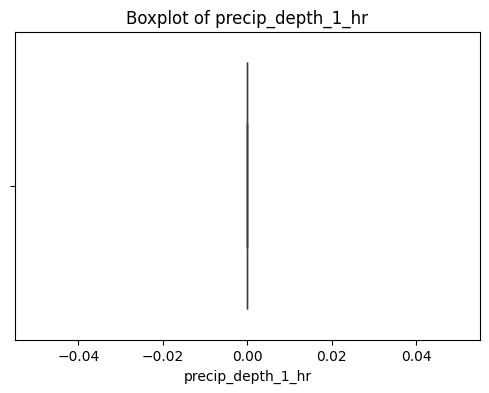

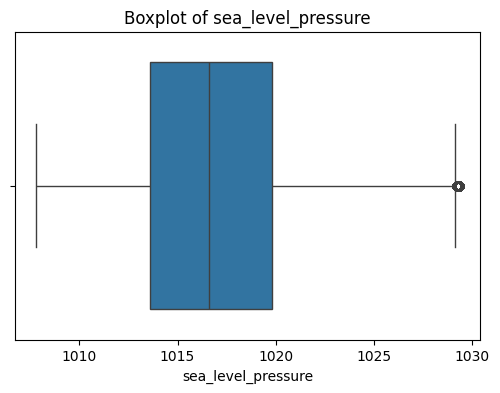

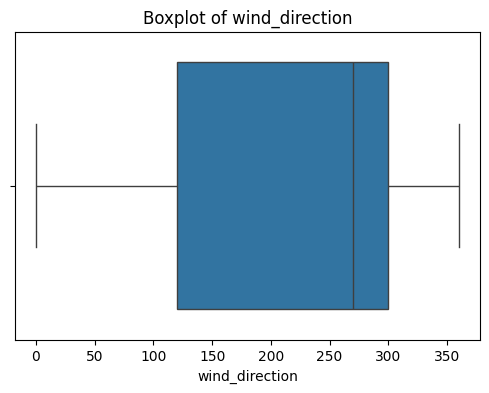

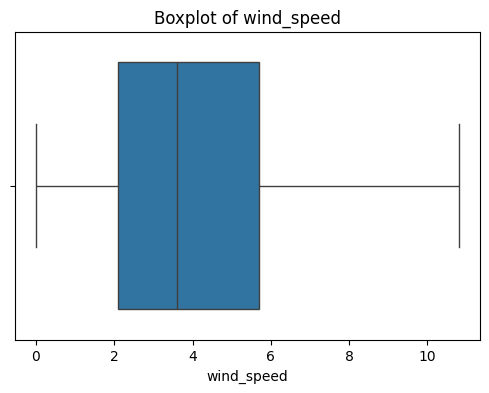

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
# numeric_cols = cp_main.select_dtypes(include=["number"]).columns
col=['meter_reading', 'square_feet', 'year_built', 'floor_count','air_temperature', 'cloud_coverage', 'dew_temperature','precip_depth_1_hr', 'sea_level_pressure', 'wind_direction','wind_speed']

# Plot each column separately
for col in col:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=cp_main[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [76]:
numeric_cols = cp_main.select_dtypes(include=["number"]).columns

# Plot each column separately
for col in numeric_cols:
    Q1 = cp_main[col].quantile(0.25)  # First quartile (25th percentile)
    Q3 = cp_main[col].quantile(0.75)  # Third quartile (75th percentile)
    IQR = Q3 - Q1  # Interquartile range
    lower_bound = Q1 - 1.5 * IQR  # Lower fence
    upper_bound = Q3 + 1.5 * IQR  # Upper fence
    
    cp_main=cp_main[(cp_main[col] >= lower_bound) & (cp_main[col] <= upper_bound)]

In [42]:
cp_main.dtypes

building_id             int64
meter                   int64
timestamp              object
meter_reading         float64
site_id                 int64
primary_use            object
square_feet             int64
year_built            float64
floor_count           float64
air_temperature       float64
cloud_coverage        float64
dew_temperature       float64
precip_depth_1_hr     float64
sea_level_pressure    float64
wind_direction        float64
wind_speed            float64
dtype: object

In [77]:
cp_main.shape

(292052, 11)

In [43]:
cp_main['precip_depth_1_hr'].unique()

array([0.])

In [44]:
cp_main.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
1907,565,0,2016-01-01 01:00:00,2.251292,4,Education,15326,1954.0,2.0,9.4,0.0,-2.2,0.0,1021.4,360.0,3.1
1908,566,0,2016-01-01 01:00:00,0.419368,4,Education,2010,1957.0,1.0,9.4,0.0,-2.2,0.0,1021.4,360.0,3.1
1909,569,0,2016-01-01 01:00:00,5.499215,4,Education,86091,1964.0,8.0,9.4,0.0,-2.2,0.0,1021.4,360.0,3.1
1910,570,0,2016-01-01 01:00:00,4.388108,4,Education,193202,1964.0,10.0,9.4,0.0,-2.2,0.0,1021.4,360.0,3.1
1911,571,0,2016-01-01 01:00:00,2.876386,4,Education,47954,1980.0,3.0,9.4,0.0,-2.2,0.0,1021.4,360.0,3.1


In [7]:
cp_main.dropna(subset=['floor_count'],inplace=True)

In [8]:
cp_main.shape

(3495553, 16)

In [9]:
cp_main["cloud_coverage"] = cp_main["cloud_coverage"].fillna(method="ffill")
cp_main["dew_temperature"] = cp_main["dew_temperature"].fillna(cp_main['dew_temperature'].mean())
# cp_main.drop(columns=['precip_depth_1_hr','air_temperature'],inplace=True)
cp_main["year_built"] = cp_main["year_built"].fillna(1959)
# cp_main['sea_level_pressure'] = cp_main['sea_level_pressure'].fillna(cp_main['sea_level_pressure'].rolling(window=5, min_periods=1).mean())
cp_main["wind_direction"] = cp_main["wind_direction"].fillna(cp_main['wind_direction'].median())
cp_main.dropna(subset=['wind_speed'],inplace=True)


C:\Users\zyzai\AppData\Local\Temp\ipykernel_20104\3270867399.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cp_main["cloud_coverage"] = cp_main["cloud_coverage"].fillna(method="ffill")


In [10]:
min_val = cp_main['sea_level_pressure'].min()
max_val = cp_main['sea_level_pressure'].max()

# Generate random values within this range for NaNs
cp_main['sea_level_pressure'] = cp_main['sea_level_pressure'].apply(
    lambda x: np.random.uniform(min_val, max_val) if np.isnan(x) else x
)

In [11]:
cp_main.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
103,105,0,2016-01-01 00:00:00,23.3036,1,Education,50623,1959.0,5.0,3.8,NaN,2.4,NaN,1020.9,240.0,3.1
104,106,0,2016-01-01 00:00:00,0.3746,1,Education,5374,1959.0,4.0,3.8,NaN,2.4,NaN,1020.9,240.0,3.1
105,106,3,2016-01-01 00:00:00,0.0000,1,Education,5374,1959.0,4.0,3.8,NaN,2.4,NaN,1020.9,240.0,3.1
106,107,0,2016-01-01 00:00:00,175.1840,1,Education,97532,2005.0,10.0,3.8,NaN,2.4,NaN,1020.9,240.0,3.1
107,108,0,2016-01-01 00:00:00,91.2653,1,Education,81580,1913.0,5.0,3.8,NaN,2.4,NaN,1020.9,240.0,3.1


precip_depth_1_hr     53.075908
air_temperature        0.012835
cloud_coverage         0.003008
building_id            0.000000
site_id                0.000000
meter                  0.000000
timestamp              0.000000
meter_reading          0.000000
year_built             0.000000
square_feet            0.000000
primary_use            0.000000
floor_count            0.000000
dew_temperature        0.000000
sea_level_pressure     0.000000
wind_direction         0.000000
wind_speed             0.000000
dtype: float64


array([[<Axes: title={'center': 'building_id'}>,
        <Axes: title={'center': 'meter'}>,
        <Axes: title={'center': 'meter_reading'}>,
        <Axes: title={'center': 'site_id'}>],
       [<Axes: title={'center': 'square_feet'}>,
        <Axes: title={'center': 'year_built'}>,
        <Axes: title={'center': 'floor_count'}>,
        <Axes: title={'center': 'air_temperature'}>],
       [<Axes: title={'center': 'cloud_coverage'}>,
        <Axes: title={'center': 'dew_temperature'}>,
        <Axes: title={'center': 'precip_depth_1_hr'}>,
        <Axes: title={'center': 'sea_level_pressure'}>],
       [<Axes: title={'center': 'wind_direction'}>,
        <Axes: title={'center': 'wind_speed'}>, <Axes: >, <Axes: >]],
      dtype=object)

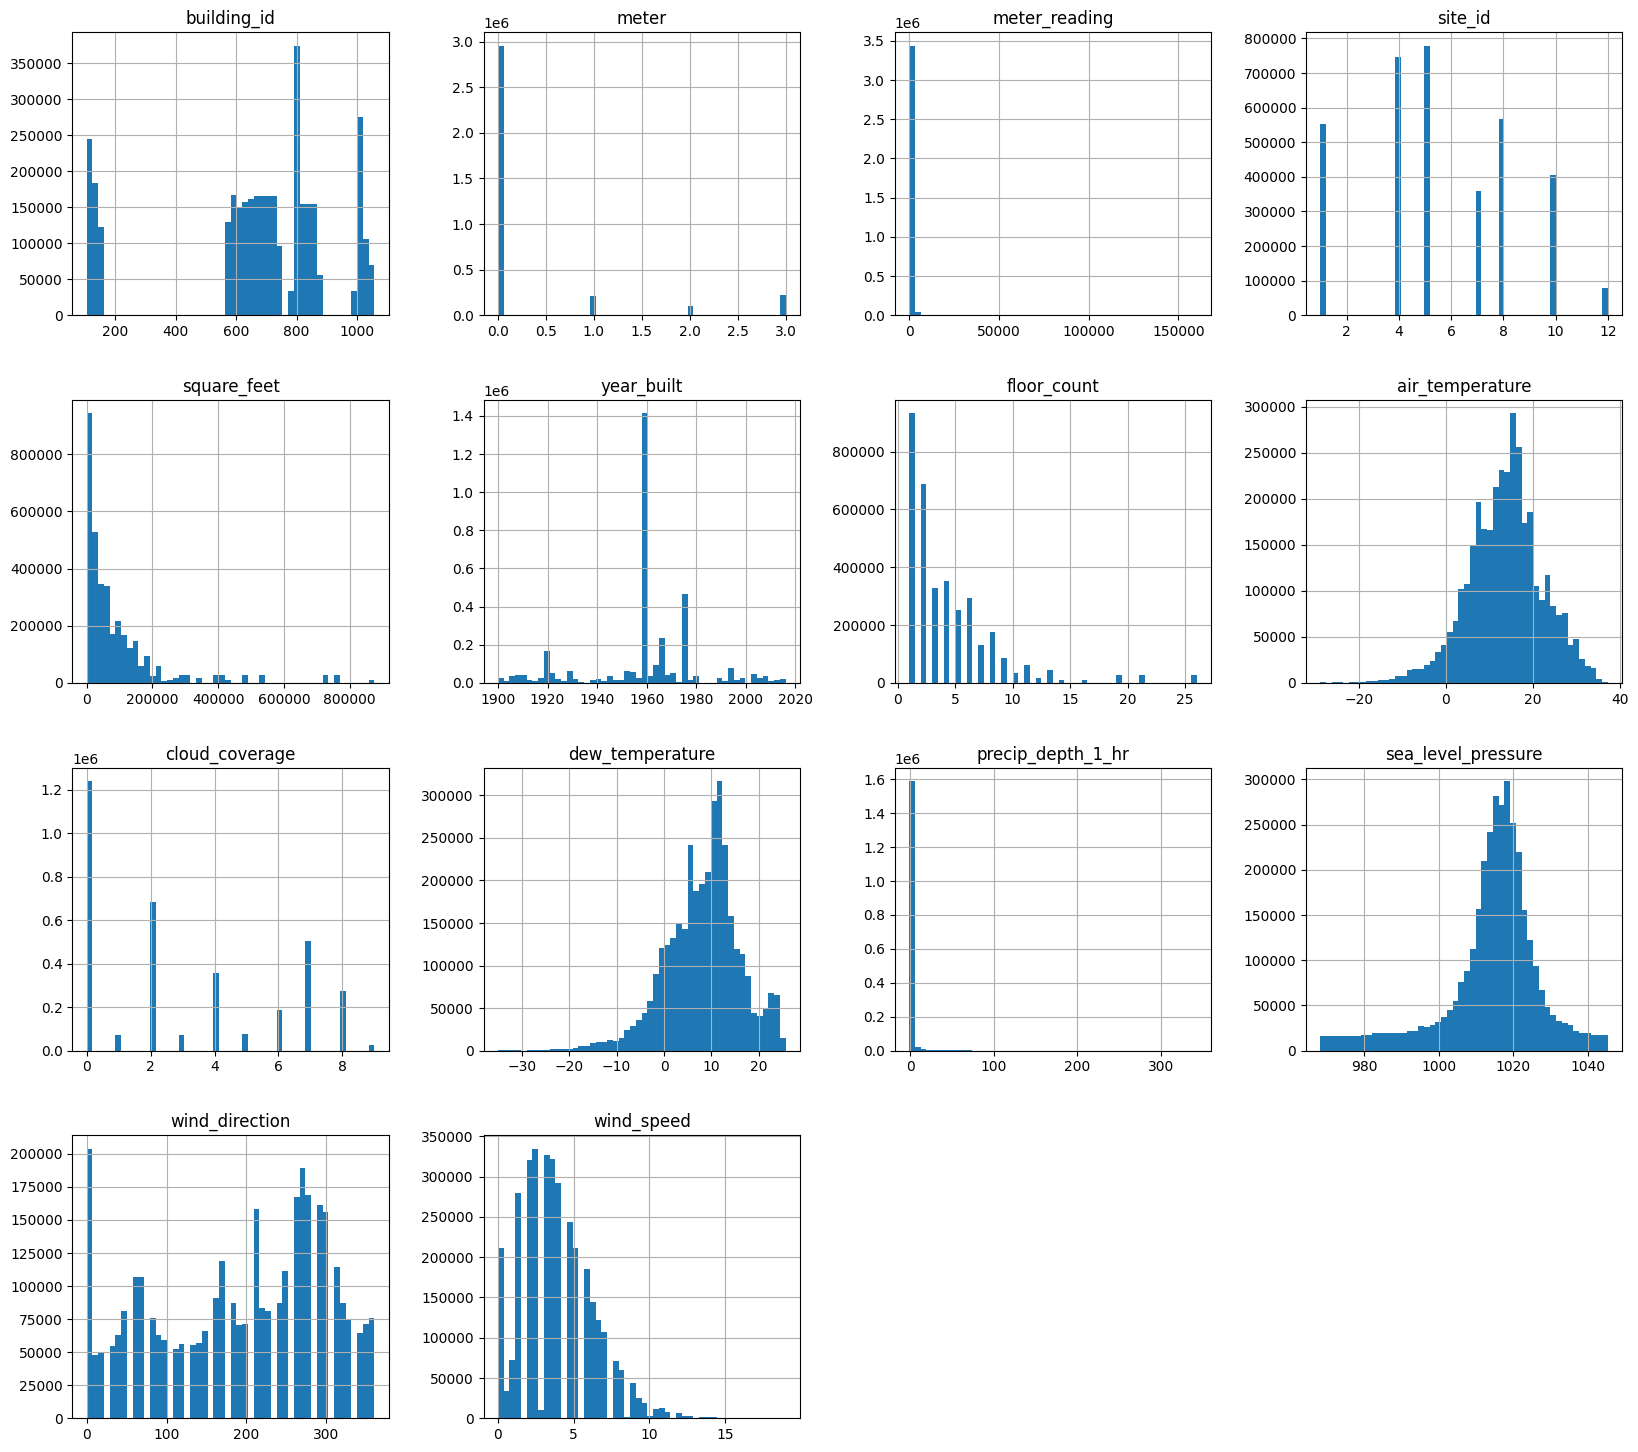

In [12]:
missing_percentage = cp_main.isnull().sum() / len(cp_main) * 100
print(missing_percentage.sort_values(ascending=False))
cp_main.hist(bins=50,figsize=(20,18))


In [13]:
cp_main.dropna(subset=['cloud_coverage'],inplace=True)


In [14]:
missing_percentage = cp_main.isnull().sum() / len(cp_main) * 100
print(missing_percentage.sort_values(ascending=False))

precip_depth_1_hr     53.074497
air_temperature        0.012835
building_id            0.000000
meter                  0.000000
site_id                0.000000
primary_use            0.000000
timestamp              0.000000
meter_reading          0.000000
year_built             0.000000
square_feet            0.000000
cloud_coverage         0.000000
floor_count            0.000000
dew_temperature        0.000000
sea_level_pressure     0.000000
wind_direction         0.000000
wind_speed             0.000000
dtype: float64


In [15]:
cp_main.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
764,804,0,2016-01-01 00:00:00,368.5830,8,Office,175618,1959.0,1.0,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
765,805,0,2016-01-01 00:00:00,5.2500,8,Entertainment/public assembly,3200,1959.0,1.0,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
766,806,0,2016-01-01 00:00:00,8.0833,8,Other,28693,1959.0,2.0,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
767,807,0,2016-01-01 00:00:00,2.7917,8,Entertainment/public assembly,3000,1959.0,1.0,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
768,808,0,2016-01-01 00:00:00,0.1250,8,Other,9357,1959.0,1.0,25.0,6.0,20.0,NaN,1019.7,0.0,0.0


In [16]:
cp_main["timestamp"] = pd.to_datetime(cp_main["timestamp"])
cp_main["hour"] = cp_main["timestamp"].dt.hour
cp_main["day"] = cp_main["timestamp"].dt.day
cp_main["month"] = cp_main["timestamp"].dt.month
cp_main["weekend"] = (cp_main["timestamp"].dt.weekday >= 5).astype(int)


In [80]:
cp_main['age']=2019-cp_main['year_built']
cp_main.drop(columns=['year_built'],inplace=True)

In [19]:
cp_main['meter_reading'].describe()

count    3.490360e+06
mean     3.500968e+00
std      2.051788e+00
min      0.000000e+00
25%      1.974081e+00
50%      3.541539e+00
75%      4.868818e+00
max      1.198410e+01
Name: meter_reading, dtype: float64

In [81]:
# features = ["meter", "hour", "day", "month", "weekend",'sea_level_pressure']
features=['floor_count','wind_speed','wind_direction','age','cloud_coverage','dew_temperature','sea_level_pressure']
target = "meter_reading"

X = cp_main[features]
y = cp_main[target]

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
drop_0readings= list(cp_main[cp_main['meter_reading']==0.0].index)
cp_main.drop(drop_0readings, axis=0, inplace=True)

In [82]:
cp_main.shape

(292052, 11)

In [25]:
cp_main['meter_reading'].value_counts()

meter_reading
4.615121    13008
2.397895    12973
1.609438    12269
1.098612    10192
1.791759     9907
            ...  
6.708792        1
8.307583        1
5.820617        1
7.580164        1
5.531043        1
Name: count, Length: 458831, dtype: int64

In [83]:
params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_estimators": 1000,
    "verbose": -1
}

# Convert to LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Train the model
# model = lgb.train(params, train_data, valid_sets=[val_data], early_stopping_rounds=50, verbose_eval=100)
model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
)


Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.39685
[200]	valid_0's rmse: 0.374885
[300]	valid_0's rmse: 0.367423
[400]	valid_0's rmse: 0.36255
[500]	valid_0's rmse: 0.358929
[600]	valid_0's rmse: 0.356463
[700]	valid_0's rmse: 0.354253
[800]	valid_0's rmse: 0.352462
[900]	valid_0's rmse: 0.351028
[1000]	valid_0's rmse: 0.34969
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 0.34969


In [84]:
from sklearn.metrics import r2_score
y_train_pred = model.predict(X_train)

# Calculate R² Score
r2 = r2_score(y_train, y_train_pred)
print("Training R² Score:", r2)
y_test_pred = model.predict(X_val)

# Calculate R² Score
r2_test = r2_score(y_val, y_test_pred)
print("Test R² Score:", r2_test)

Training R² Score: 0.9600659793316563
Test R² Score: 0.9577484642220992
